Sampling rate: 16000


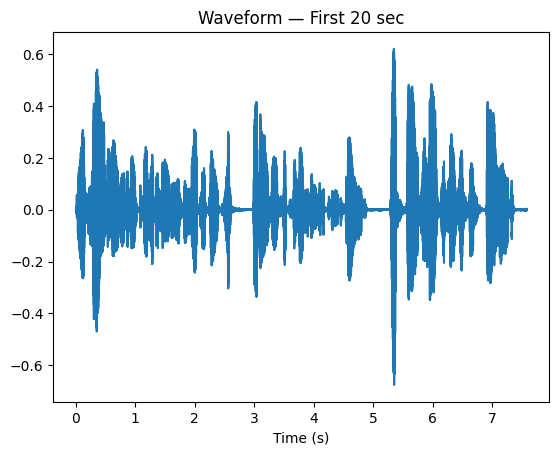

Total frames: 756
Voiced frames: 25
Unvoiced frames: 731


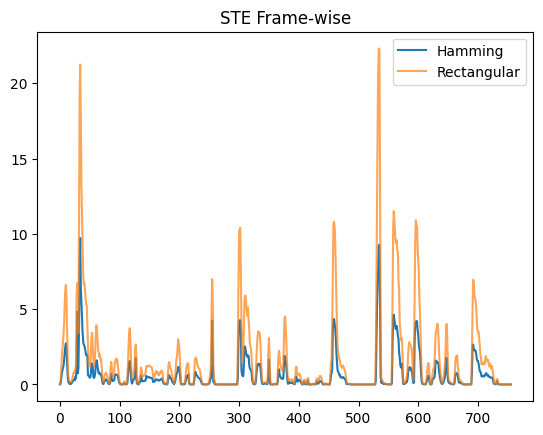

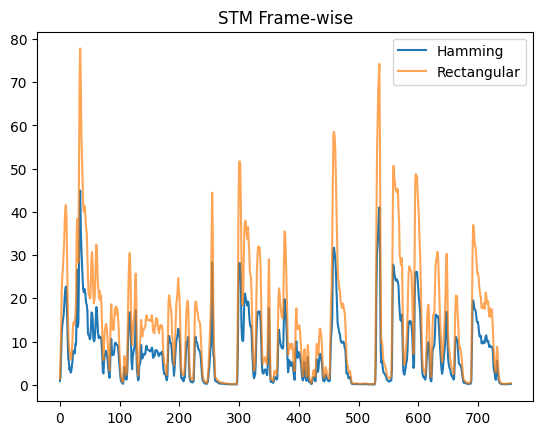

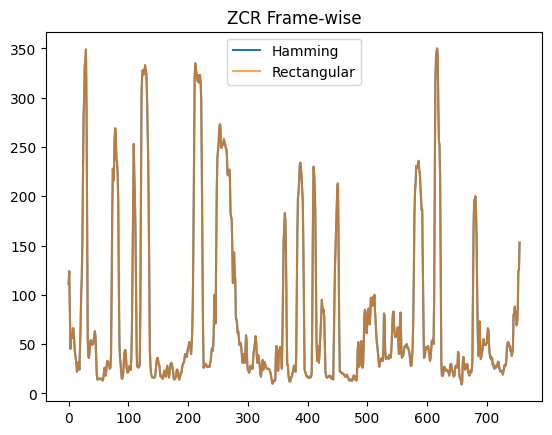

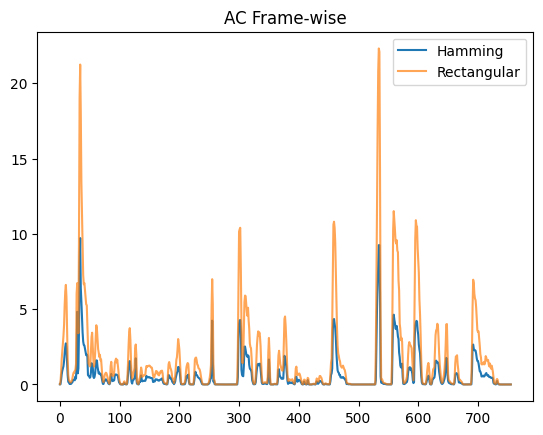

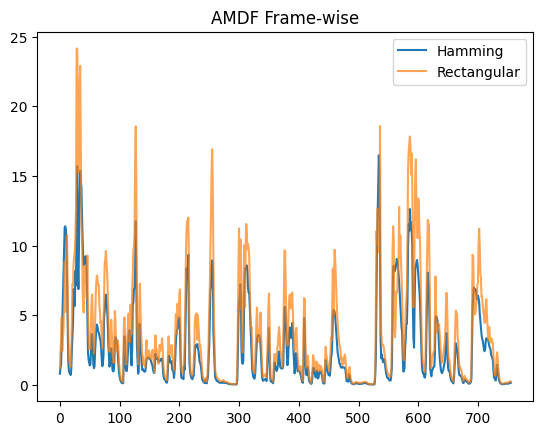

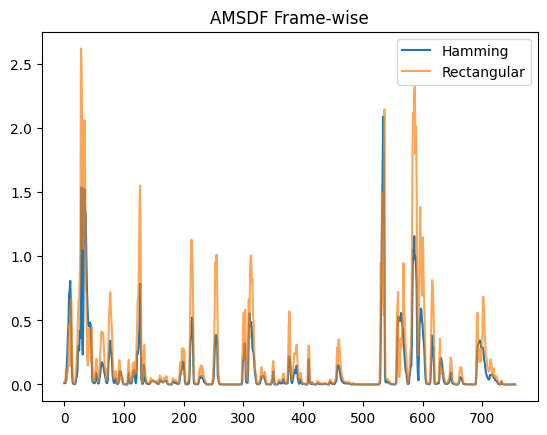

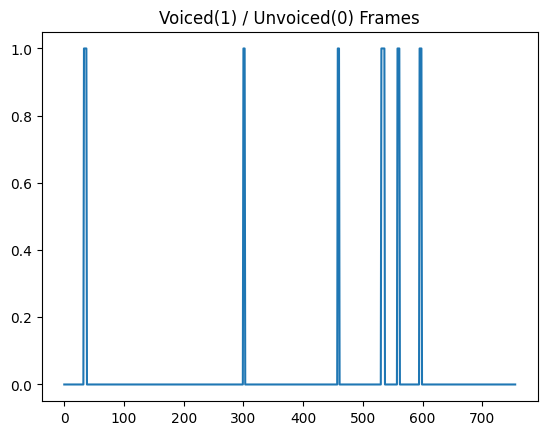

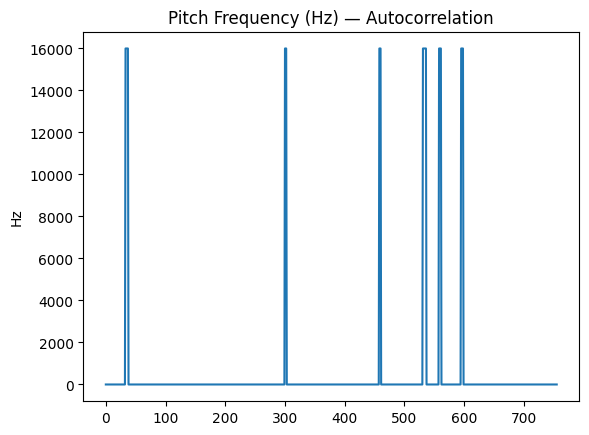

Average pitch (voiced): 16000.0


In [1]:
import numpy as np
import librosa
import matplotlib.pyplot as plt

# -----------------------------
# SETTINGS
# -----------------------------
FILE = "/content/LJ037-0171.wav"   # <-- change to your file
SR = 16000
FRAME_MS = 25
SHIFT_MS = 10
MAX_LAG = 200   # for pitch search

# -----------------------------
# LOAD SPEECH (first 20 sec)
# -----------------------------
x, sr = librosa.load(FILE, sr=SR)
x = x[:20 * sr]

print("Sampling rate:", sr)

t = np.arange(len(x)) / sr
plt.figure()
plt.plot(t, x)
plt.title("Waveform — First 20 sec")
plt.xlabel("Time (s)")
plt.show()

# -----------------------------
# FRAME PARAMS
# -----------------------------
frame_len = int(sr * FRAME_MS / 1000)
frame_shift = int(sr * SHIFT_MS / 1000)

num_frames = int((len(x) - frame_len) / frame_shift) + 1
print("Total frames:", num_frames)

# -----------------------------
# FRAMING
# -----------------------------
frames = np.array([
    x[i*frame_shift:i*frame_shift+frame_len]
    for i in range(num_frames)
])

# -----------------------------
# WINDOWS
# -----------------------------
ham = np.hamming(frame_len)
rect = np.ones(frame_len)

frames_ham = frames * ham
frames_rect = frames * rect

# -----------------------------
# FEATURE FUNCTIONS
# -----------------------------
def STE(f):
    return np.sum(f**2)

def STM(f):
    return np.sum(np.abs(f))

def ZCR(f):
    return np.sum(np.abs(np.diff(np.sign(f))))/2

def autocorr_full(f):
    return np.correlate(f, f, mode="full")[len(f)-1:]

def amdf_curve(f, max_lag):
    return [np.sum(np.abs(f[k:] - f[:-k])) for k in range(1, max_lag)]

def amsdf_curve(f, max_lag):
    return [np.sum((f[k:] - f[:-k])**2) for k in range(1, max_lag)]

# -----------------------------
# EXTRACT FEATURES FRAMEWISE
# -----------------------------
def extract(frames):
    ste, stm, zcr = [], [], []
    ac_peak, amdf_min, amsdf_min = [], [], []
    pitch_ac, pitch_amdf, pitch_amsdf = [], [], []

    for f in frames:
        ste.append(STE(f))
        stm.append(STM(f))
        zcr.append(ZCR(f))

        # autocorr
        ac = autocorr_full(f)
        ac_peak.append(np.max(ac))

        # pitch from autocorr (ignore lag0)
        lag = np.argmax(ac[1:MAX_LAG]) + 1
        pitch_ac.append(sr/lag if lag>0 else 0)

        # AMDF
        amdf = amdf_curve(f, MAX_LAG)
        amdf_min.append(np.min(amdf))
        lag_a = np.argmin(amdf)+1
        pitch_amdf.append(sr/lag_a if lag_a>0 else 0)

        # AMSDF
        amsdf = amsdf_curve(f, MAX_LAG)
        amsdf_min.append(np.min(amsdf))
        lag_s = np.argmin(amsdf)+1
        pitch_amsdf.append(sr/lag_s if lag_s>0 else 0)

    return {
        "STE":ste,
        "STM":stm,
        "ZCR":zcr,
        "AC":ac_peak,
        "AMDF":amdf_min,
        "AMSDF":amsdf_min,
        "P_AC":pitch_ac,
        "P_AMDF":pitch_amdf,
        "P_AMSDF":pitch_amsdf
    }

feat_ham = extract(frames_ham)
feat_rect = extract(frames_rect)

# -----------------------------
# PERIODIC / VOICED DETECTION
# -----------------------------
energy = np.array(feat_ham["STE"])
zcr_vals = np.array(feat_ham["ZCR"])

E_th = 0.4 * np.max(energy)
Z_th = np.mean(zcr_vals)

voiced = (energy > E_th) & (zcr_vals < Z_th)

print("Voiced frames:", np.sum(voiced))
print("Unvoiced frames:", np.sum(~voiced))

# -----------------------------
# PLOT FEATURES (both windows)
# -----------------------------
names = ["STE","STM","ZCR","AC","AMDF","AMSDF"]

for name in names:
    plt.figure()
    plt.plot(feat_ham[name], label="Hamming")
    plt.plot(feat_rect[name], label="Rectangular", alpha=0.7)
    plt.title(name + " Frame-wise")
    plt.legend()
    plt.show()

# -----------------------------
# PLOT VOICED / UNVOICED
# -----------------------------
plt.figure()
plt.plot(voiced.astype(int))
plt.title("Voiced(1) / Unvoiced(0) Frames")
plt.show()

# -----------------------------
# PITCH ESTIMATION (only voiced)
# -----------------------------
pitch_vals = np.array(feat_ham["P_AC"])
pitch_vals[~voiced] = 0

plt.figure()
plt.plot(pitch_vals)
plt.title("Pitch Frequency (Hz) — Autocorrelation")
plt.ylabel("Hz")
plt.show()

print("Average pitch (voiced):",
      np.mean(pitch_vals[pitch_vals>0]))
